<a href="https://colab.research.google.com/github/varshabelvai01/internshipproject/blob/main/weather_rainfall_project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Dataset

In [ ]:
import os

csv_file_path=os.path.join("weather_dataset.csv")
df = pd.read_csv(csv_file_path)

df.head()

,Day,Pressure,MaxTemp,MinTemp,DewPoint,Humidity,Cloud,Rainfall,Sunshine,WindDirection,WindSpeed,Rain
0,1,1018,30,19,23,45,56,6.245612,0.835178,238,7,Yes
1,2,997,32,27,19,41,74,4.049550,10.403047,238,11,Yes
2,3,1015,31,22,15,67,13,13.267972,2.633845,233,31,Yes
3,4,999,35,26,19,56,30,7.748731,4.952417,52,12,No
4,5,993,35,20,21,64,36,0.753458,3.779853,212,39,No


In [ ]:
df['Rain'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df.shape

(366, 12)

In [ ]:
df.memory_usage()

Index             128
Day              2928
Pressure         2928
MaxTemp          2928
MinTemp          2928
DewPoint         2928
Humidity         2928
Cloud            2928
Rainfall         2928
Sunshine         2928
WindDirection    2928
WindSpeed        2928
Rain             2928
dtype: int64

In [ ]:
df.describe()

,Day,Pressure,MaxTemp,MinTemp,DewPoint,Humidity,Cloud,Rainfall,Sunshine,WindDirection,WindSpeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,183.500000,1009.956284,33.448087,23.456284,20.095628,65.390710,49.325137,9.395600,5.721828,188.259563,18.939891
std,105.799338,10.985582,3.395611,3.480986,3.106182,15.588293,29.336139,5.721238,3.380122,101.581823,11.737386
min,1.000000,990.000000,28.000000,18.000000,15.000000,40.000000,0.000000,0.007074,0.033697,1.000000,0.000000
25%,92.250000,1001.000000,30.000000,21.000000,17.000000,51.000000,22.000000,4.240491,2.866207,107.250000,8.000000
50%,183.500000,1011.000000,33.500000,23.000000,20.000000,65.000000,47.000000,9.136142,5.643598,190.000000,19.000000
75%,274.750000,1019.000000,36.000000,26.000000,23.000000,79.000000,76.000000,14.339831,8.611881,273.750000,29.000000
max,366.000000,1029.000000,39.000000,29.000000,25.000000,94.000000,99.000000,19.978978,11.988287,359.000000,39.000000


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

Day              0
Pressure         0
MaxTemp          0
MinTemp          0
DewPoint         0
Humidity         0
Cloud            0
Rainfall         0
Sunshine         0
WindDirection    0
WindSpeed        0
Rain             0
dtype: int64

# Data Cleaning

In [ ]:
df['Rain'] = df['Rain'].astype(str).str.strip().map({'Yes':1,'No':0})

In [ ]:
df.head()

,Day,Pressure,MaxTemp,MinTemp,DewPoint,Humidity,Cloud,Rainfall,Sunshine,WindDirection,WindSpeed,Rain
0,1,1018,30,19,23,45,56,6.245612,0.835178,238,7,1
1,2,997,32,27,19,41,74,4.049550,10.403047,238,11,1
2,3,1015,31,22,15,67,13,13.267972,2.633845,233,31,1
3,4,999,35,26,19,56,30,7.748731,4.952417,52,12,0
4,5,993,35,20,21,64,36,0.753458,3.779853,212,39,0


 # Data Visualization

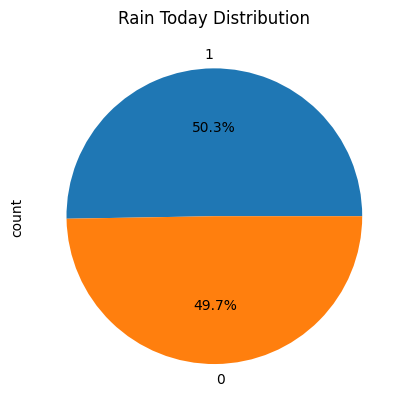

In [ ]:
df['Rain'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Rain Today Distribution")
plt.show()

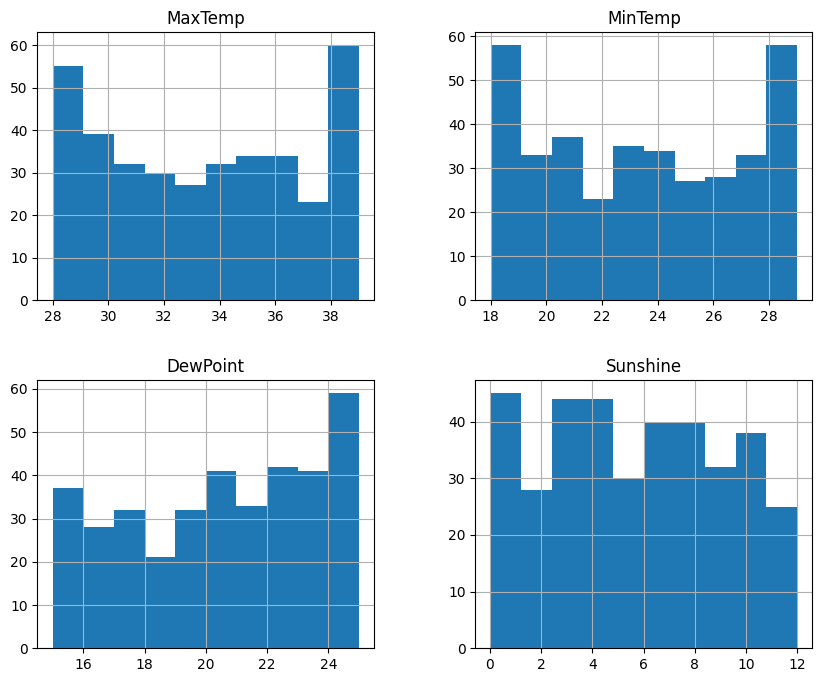

In [ ]:
df[['MaxTemp','MinTemp','DewPoint','Sunshine']].hist(figsize=(10,8))
plt.show()

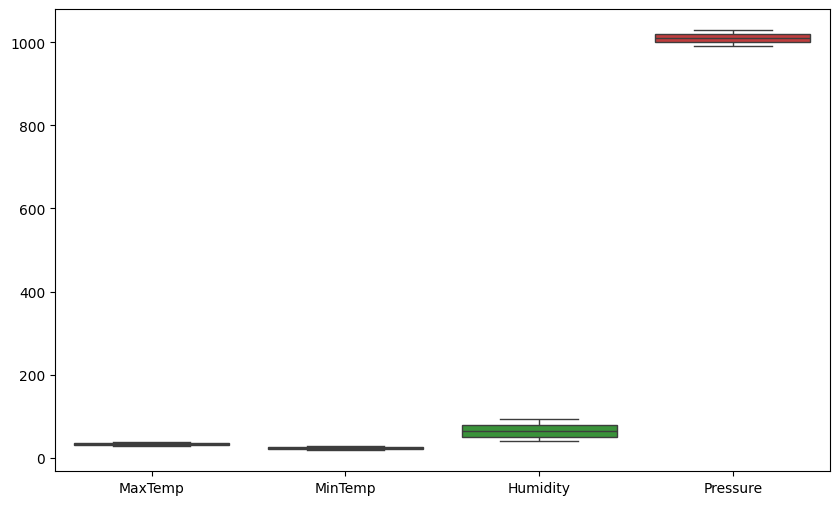

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['MaxTemp','MinTemp','Humidity','Pressure']])
plt.show()

# Correlation Analysis

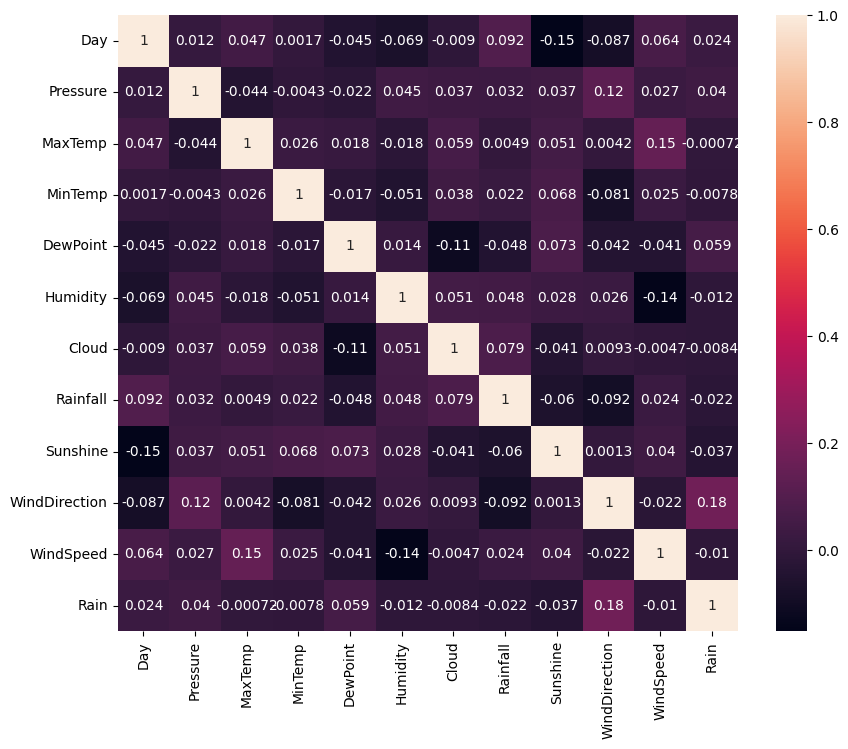

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
df.drop(['MaxTemp','MinTemp'], axis=1, inplace=True)

In [ ]:
df.columns

Index(['Day', 'Pressure', 'DewPoint', 'Humidity', 'Cloud', 'Rainfall',
       'Sunshine', 'WindDirection', 'WindSpeed', 'Rain'],
      dtype='object')

# Splitting Data into Training and Testing

In [ ]:
X = df.drop('Rain', axis=1)
y = df['Rain']

X.head()
y.head()

0    1
1    1
2    1
3    0
4    0
Name: Rain, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X.shape

(366, 9)

In [ ]:
y.shape

(366,)

In [ ]:
X.head()

,Day,Pressure,DewPoint,Humidity,Cloud,Rainfall,Sunshine,WindDirection,WindSpeed
0,1,1018,23,45,56,6.245612,0.835178,238,7
1,2,997,19,41,74,4.049550,10.403047,238,11
2,3,1015,15,67,13,13.267972,2.633845,233,31
3,4,999,19,56,30,7.748731,4.952417,52,12
4,5,993,21,64,36,0.753458,3.779853,212,39


# Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
pred = lr.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)

0.5

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
pred = xgb.predict(X_test)
accuracy_score(y_test, pred)

0.5945945945945946

In [ ]:
from sklearn.svm import SVC

svc = SVC(probability=True)
svc.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
pred = svc.predict(X_test)
accuracy_score(y_test, pred)

0.6756756756756757

# Model Evaluation

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.69      0.65      0.67        37
           1       0.67      0.70      0.68        37

    accuracy                           0.68        74
   macro avg       0.68      0.68      0.68        74
weighted avg       0.68      0.68      0.68        74



# Confusion Matrix

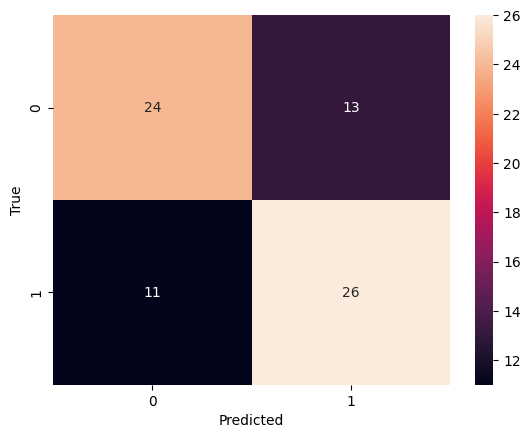

In [ ]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()